# The Vanishing Penny 🪙
### How fast does a *guaranteed* Polymarket arbitrage close — and could you ever catch it?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Execution--moat: Confirmed](https://img.shields.io/badge/Execution--moat-Confirmed-8b949e?style=flat-square)

Every few weeks a thread goes viral with the same hook: on Polymarket, when **YES costs \$0.62 and NO costs \$0.33**, that's only \$0.95 — so buying both guarantees a **free \$0.05** when the market settles at \$1. It's true: a [real 2025 paper](../docs/references.md) documents **\$40 million** pulled out this way in a year. So we asked the one question the thread skips — **how long does the free nickel actually sit there before someone faster takes it?**

> 📓 **This is the plain-language layer.** Want the statistics, the microstructure and the capacity maths? That's the companion notebook, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** An educational, reproducible research tool: every chart below is generated by the code beside it. The reproducible core runs on a **synthetic** market with a *baked-in* 6-minute half-life (the cached real prices are git-ignored) — on purpose: that's where our stopwatch *works*, proving the code, so the real-world result (quoted from [`../docs/results.md`](../docs/results.md)) is a fact about the market, not a bug. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (prediction_arb/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from prediction_arb import data, arbitrage, robustness

# Offline synthetic book: arbitrage gaps that decay with a KNOWN 6-minute half-life. This
# is where the estimator SHOULD work -- so it validates the machinery. The real verdict
# (the penny closes below the 1-minute tape floor) is in ../docs/results.md via verify_real.py.
gap, truth = data.synthetic_markets(seed=0)
print(f"{gap.shape[1]} markets x {gap.shape[0]} minutes, baked-in half-life = {truth.half_life_min} min")


48 markets x 6000 minutes, baked-in half-life = 6.0 min


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Is the free money real? | ✅ **Yes** — risk-free by construction, ~\$40M documented, and **161** real gaps opened on our own tape. |
| Can our stopwatch measure how fast it closes? | ✅ **Yes** — on the synthetic, it recovers the baked-in 6-minute half-life exactly. |
| How long does a *real* gap last? | ❌ **Under a minute** — 100% of real episodes are gone by the next minute-sample. |
| Could *you* grab it? | ❌ **No** — react in 5 minutes and you keep **3%** of the nickel; in 30 minutes, basically nothing. |

> Desk shorthand: **Signal `REAL` · Tradability `MIRAGE` · Execution-moat `CONFIRMED`** — let's see the method earn them.

## 1 · The claim 📣

A viral thread (2.9M views) lays out *"the exact maths that pulled \$40,000,000 out of Polymarket."* The core is genuinely true: `YES + NO < \$1` is a risk-free trade, it's in a real paper, and the winning wallets are public on-chain — the top one made **\$2M over 4,049 trades**. Then the thread pivots to a sign-up link and an "airdrop." Our job is the gap between *"this is real"* and *"so you can do it."*

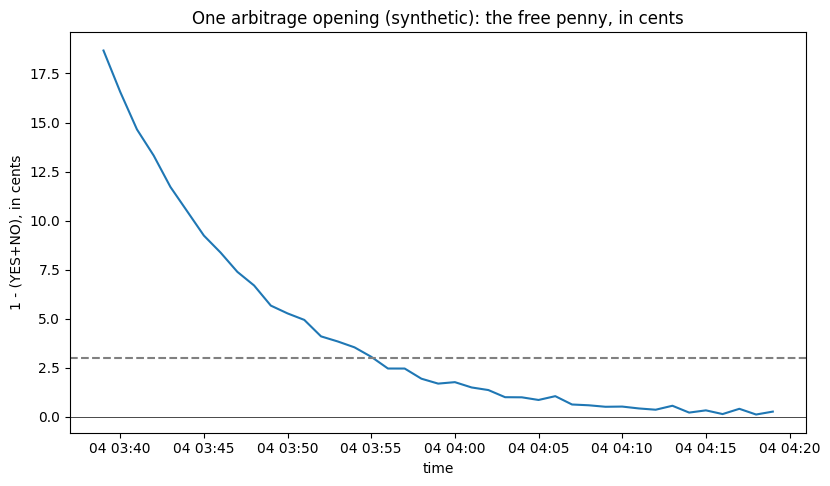

peak penny 18.7c, gone in ~17 min


In [2]:
g = gap['MKT00']
ep = arbitrage.detect_episodes(g, open_threshold=0.03, name='MKT00')
e = max(ep, key=lambda e: abs(e.peak))
win = g.loc[e.t_open: e.t_open + pd.Timedelta(minutes=40)]
plt.plot(win.index, 100*win.values)
plt.axhline(3, ls='--', c='grey'); plt.axhline(0, c='k', lw=0.5)
plt.title('One arbitrage opening (synthetic): the free penny, in cents')
plt.ylabel('1 - (YES+NO), in cents'); plt.xlabel('time'); plt.show()
print(f'peak penny {abs(e.peak)*100:.1f}c, gone in ~{e.duration} min')

A gap snaps open, then bleeds back to zero as arbitrageurs close it. The only question that matters is the **slope of that decay** — its half-life.

## 2 · So what? 💰

If the nickel sat there for a minute or two, this would be the cleanest free lunch in markets: risk-free, documented at \$40M, open to anyone with a wallet. If instead it's gone in **seconds**, the same \$40M is the opposite lesson — a real edge that is *entirely* about **execution speed**, where everyone slow is just feeding the fast wallets their exit. The arbitrage being real is exactly what makes the retail pitch dangerous: the maths check out, so you never suspect the catch.

## 3 · How we'd know 🔍

We measure the **half-life** of the gap — minutes until an opened mispricing has shrunk by half. The rule, set in advance: if it's comfortably longer than a human reaction, the penny is **reachable**; if it's at or below the finest tape we can sample (1 minute), it's a **mirage** for anyone not racing the 2-second block. We prove the stopwatch on the synthetic first, where we know the answer is 6 minutes.

episodes: 1647
recovered half-life: 6.0 min (baked in: 6.0 min)


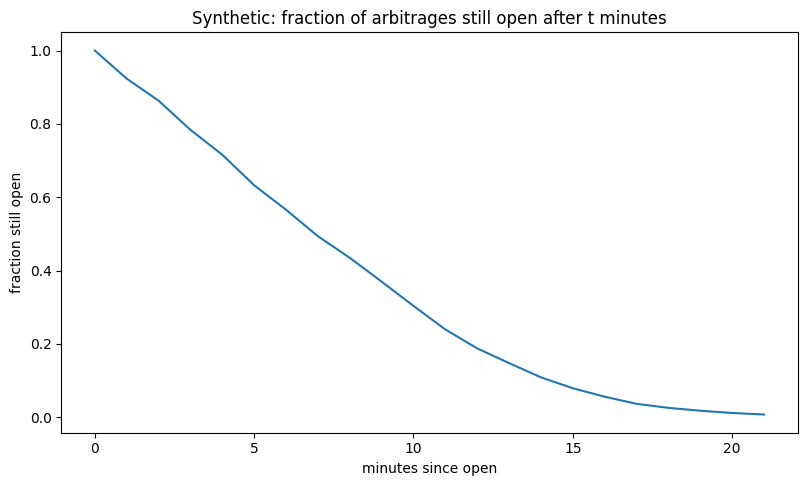

In [3]:
eps = arbitrage.detect_all(gap, open_threshold=truth.open_threshold)
print(f'episodes: {len(eps)}')
print(f"recovered half-life: {arbitrage.time_to_half(eps):.1f} min "
      f"(baked in: {truth.half_life_min} min)")
robustness.survival_curve(eps)['frac_open'].plot(
    title='Synthetic: fraction of arbitrages still open after t minutes')
plt.xlabel('minutes since open'); plt.ylabel('fraction still open'); plt.show()

## 4 · The teardown 🔬

On the synthetic the stopwatch nails the baked-in 6 minutes — the machinery is sound. Now the real world, quoted from the reproducible run ([`../docs/results.md`](../docs/results.md), via `examples/verify_real.py`):

- **The penny is real:** 13 markets, **161** gaps clear 3¢, median **4¢**.
- **And gone by the next sample:** **100%** of episodes are *below the 1-minute floor* — median duration **1 minute**, too short to even *see* halving.
- **The tell:** coarsen the tape and the median episode is *one tick* at every resolution (1, 2, 5, 15, 30, 60 min) while the count collapses **161 → 2**. Its true lifetime is below *anything* we can sample.
- **So you keep almost none of it:** even granting a generous 1-minute half-life, a 5-minute reaction keeps **3%**, a 30-minute reaction **~0%**.

In [4]:
print('retail capture vs reaction latency (generous 1-min half-life):')
display(robustness.retail_capture_table(1.0).round(4))

retail capture vs reaction latency (generous 1-min half-life):


,capture_frac
latency_min,
0.0005,0.9997
0.5000,0.7071
1.0000,0.5000
2.0000,0.2500
5.0000,0.0312
10.0000,0.0010
30.0000,0.0000


## 5 · The verdict ⚖️

**Signal `REAL`** — the free money exists, no argument. **Tradability `MIRAGE`** — it closes below the 1-minute tape floor, so a human keeps ~0 of it. **Execution-moat `CONFIRMED`** — a lifetime that hides under any tape is a prize reserved for the ~30-millisecond wallets. The rare case where the signal is bulletproof and the mirage is *entirely* in who can reach it.

## 6 · Could you trade it? 🏦

No — and not because it's fake. Polymarket's order book fills your two legs **one at a time**: you buy YES at \$0.30, the book moves, your NO fills at \$0.78, and the guaranteed \$0.40 is now a loss. The fast wallets dodge this by firing both legs inside one 2-second block from a 30-ms loop; even *they* miss **45%** of the combinatorial trades. Copy-trading fails too — you see the fill a block late and buy from the very wallet you copied. And the thread's real ask isn't a trade; it's a wallet connect and an "airdrop." The product is you.

## 7 · Going further 🚪

- **Measure it directly:** rebuild the gap from on-chain `OrderFilled` events and clock the half-life in *seconds* instead of bounding it at a minute.
- **The bigger pot:** the \$29M *combinatorial* arbitrage (across linked markets), untouched here.
- **Crisis test:** does the gap last any longer when a whole market dislocates at once (election night, a sports final)?

The deep version — both estimators, the bootstrap, the resolution sweep, the capture math — is in [`02_for_the_quants.ipynb`](02_for_the_quants.ipynb).